# Calibrating an optical potential with `CalibrationConfig`: emcee vs dynesty

This notebook shows how `CalibrationConfig` acts as a **uniform interface** to
external inference libraries.  We calibrate a nuclear optical-model potential
to mock $n + {}^{40}$Ca elastic differential cross-section data using both
[emcee](https://emcee.readthedocs.io/) (MCMC using ensemble sampling) and
[dynesty](https://dynesty.readthedocs.io/) (nested sampling), then compare the
resulting posteriors and predictive posterior bands.

The key interface points provided by `CalibrationConfig`:

| sampler | method used |
|---------|-------------|
| emcee   | `config.log_posterior`, `config.starting_location` |
| dynesty | `config.log_likelihood`, `config.prior_transform`, `config.ndim` |

In [1]:
import corner
import dynesty
from dynesty import plotting as dyplot
import emcee
import jitr
import matplotlib.pyplot as plt
import numpy as np
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)

import rxmc
from rxmc.config import CalibrationConfig, ParameterConfig
from rxmc.params import Parameter
from rxmc.priors import TruncatedNormalPrior

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## Reaction, optical-model, and mock data

We use the same minimal optical-model potential setup as in
`30s_optical_potential_calibration.ipynb`.

In [2]:
Ca40 = (40, 20)
neutron = (1, 0)
E_lab = 14.1

rxn = jitr.reactions.ElasticReaction(target=Ca40, projectile=neutron)

mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central_potential(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) + (
        4j * ad * Wd
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit_potential(r, Vso, Wso, Rso, aso):
    return (Vso + 1j * Wso) * mso**2 * thomas_safe(r, Rso, aso)


R = 1.2 * 40 ** (1 / 3)
fixed_spin_orbit = (6.0, -3, R, 0.45)


def extract_params(ws, *x):
    Vv, Wv, Rv, av, Wd, Rd, ad = x
    return (Vv, Wv, Rv, av, Wd, Rd, ad), fixed_spin_orbit


params = [
    Parameter("Vv", unit="MeV"),
    Parameter("Wv", unit="MeV"),
    Parameter("Rv", unit="fm"),
    Parameter("av", unit="fm"),
    Parameter("Wd", unit="MeV"),
    Parameter("Rd", unit="fm"),
    Parameter("ad", unit="fm"),
]

omp = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=central_potential,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=extract_params,
    params=params,
    model_name="minimal_elastic_demo",
)

In [3]:
angles_deg = np.linspace(2.0, 160.0, 28)
true_params = np.array(
    [48.0, 3.5, 1.1 * 40 ** (1 / 3), 0.7, 21, 1.2 * 40 ** (1 / 3), 0.5]
)

template_obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    x=angles_deg,
    y=np.ones_like(angles_deg, dtype=float),
    Elab=E_lab,
    reaction=rxn,
    quantity="dXS/dA",
    measurement_quantity="dXS/dA",
    y_units="barn / steradian",
    dataset_label="template",
)

y_true = omp.evaluate(template_obs, *true_params)

rng = np.random.default_rng(42)
y_stat_err = 0.2 * np.maximum(y_true, 1e-4)
y_mock = np.clip(y_true + rng.normal(scale=y_stat_err * 1.3), 1e-6, None)

obs = rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
    x=angles_deg,
    y=y_mock,
    Elab=E_lab,
    reaction=rxn,
    quantity="dXS/dA",
    measurement_quantity="dXS/dA",
    y_units="barn / steradian",
    y_stat_err=y_stat_err,
    dataset_label="mock elastic dataset",
)

Text(0.5, 1.0, 'Mock $n + {}^{40}$Ca differential cross-section data')

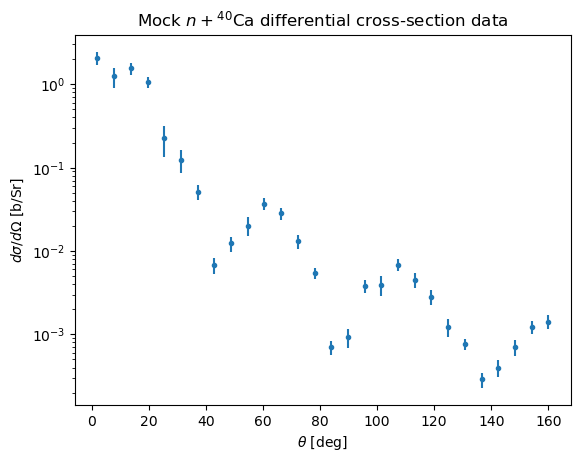

In [4]:
plt.errorbar(np.rad2deg(obs.x), obs.y, obs.y_stat_err, linestyle="none", marker=".")
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [b/Sr]")
plt.yscale("log")
plt.title(r"Mock $n + {}^{40}$Ca differential cross-section data")

## Build `CalibrationConfig`

We use `TruncatedNormalPrior` here to enforce physical constraints.

In [5]:
prior_mean = np.array(
    [50.0, 3.0, 1.2 * 40 ** (1 / 3), 0.65, 18.0, 1.2 * 40 ** (1 / 3), 0.65]
)
prior_std = np.array([7.0, 7.0, 0.5, 0.20, 10.0, 0.5, 0.20])
lower = np.zeros_like(prior_mean)
upper = prior_mean + 10 * prior_std

prior = TruncatedNormalPrior(
    mu=prior_mean,
    sigma=prior_std,
    lower=lower,
    upper=upper,
    seed=0,
)

model_config = ParameterConfig(
    params=omp.params,
    prior=prior,
    initial_proposal_distribution=prior,
)

constraint = rxmc.constraint.Constraint(
    observations=[obs],
    physical_model=omp,
    likelihood_model=rxmc.likelihood_model.LikelihoodModel(),
)
evidence = rxmc.evidence.Evidence(constraints=[constraint])

config = CalibrationConfig(evidence=evidence, model_config=model_config)

print("ndim:", config.ndim)
print("parameters:", config.parameter_names)
print("prior objects:", [type(p).__name__ for p in config.prior])

ndim: 7
parameters: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad']
prior objects: ['TruncatedNormalPrior']


## emcee: ensemble MCMC

`CalibrationConfig.log_posterior` is passed directly as the log-probability
function; `CalibrationConfig.starting_location` generates the initial walker
positions by drawing from the proposal distribution.

In [6]:
nwalkers = 32
nsteps = 3000

p0 = config.starting_location(nwalkers)

sampler_emcee = emcee.EnsembleSampler(
    nwalkers,
    config.ndim,
    config.log_posterior,
)
state = sampler_emcee.run_mcmc(p0, nsteps, progress=True)

100%|██████████| 3000/3000 [02:42<00:00, 18.45it/s]


In [7]:
tau = sampler_emcee.get_autocorr_time(quiet=True)
burnin = int(2 * np.max(tau))
thin = max(1, int(0.5 * np.min(tau)))
flat_emcee = sampler_emcee.get_chain(discard=burnin, thin=thin, flat=True)

print(f"Autocorrelation times: {np.round(tau, 1)}")
print(f"Burn-in: {burnin}  thin: {thin}")
print(f"Posterior samples: {len(flat_emcee)}")
print(f"Mean acceptance fraction: {sampler_emcee.acceptance_fraction.mean():.3f}")

The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [143.28774007 125.29298592 131.92521034 122.07893668 138.89829474
 108.9721398  140.79693347]


Autocorrelation times: [143.3 125.3 131.9 122.1 138.9 109.  140.8]
Burn-in: 286  thin: 54
Posterior samples: 1600
Mean acceptance fraction: 0.333


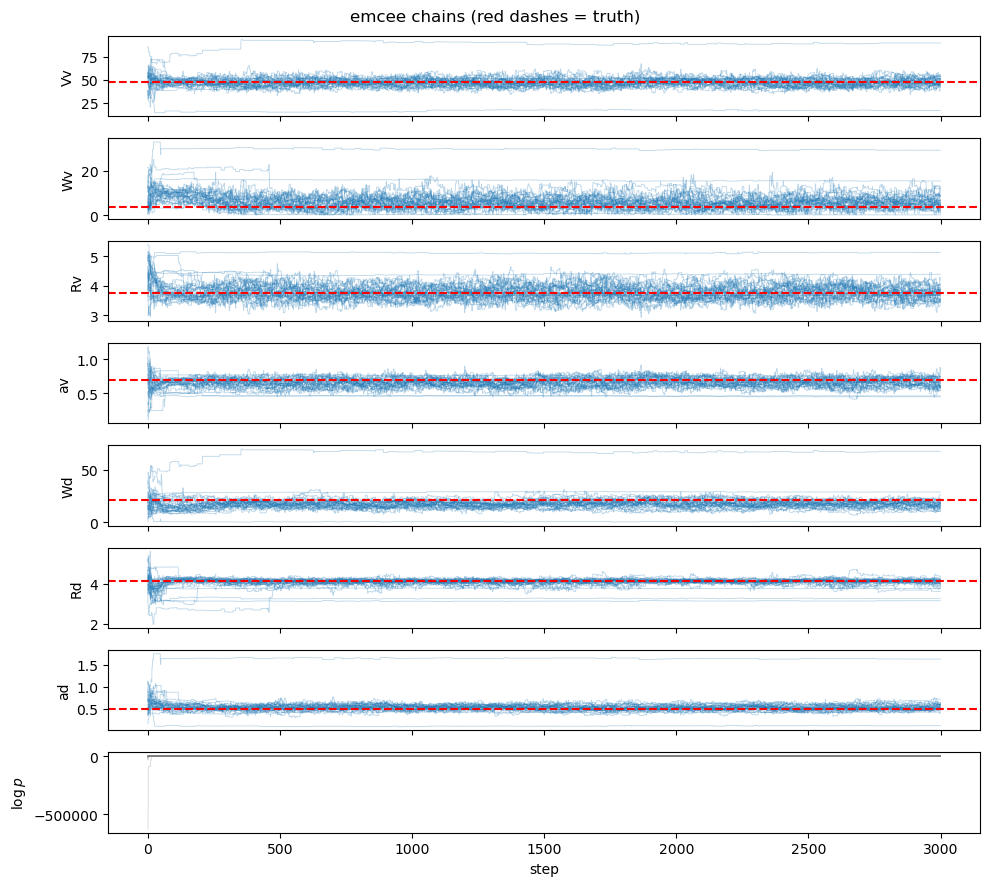

In [8]:
chain = sampler_emcee.get_chain()
logp_chain = sampler_emcee.get_log_prob()

fig, axes = plt.subplots(config.ndim + 1, 1, figsize=(10, 9), sharex=True)
for i, (ax, name) in enumerate(zip(axes[:-1], config.parameter_names)):
    ax.plot(chain[:, :, i], alpha=0.3, lw=0.6, color="tab:blue")
    ax.axhline(true_params[i], color="r", lw=1.5, linestyle="--")
    ax.set_ylabel(name)
axes[-1].plot(logp_chain, alpha=0.3, lw=0.6, color="tab:gray")
axes[-1].set_ylabel(r"$\log p$")
axes[-1].set_xlabel("step")
fig.suptitle("emcee chains (red dashes = truth)")
fig.tight_layout()

## dynesty: nested sampling

`CalibrationConfig.log_likelihood` and `CalibrationConfig.prior_transform`
provide the two functions dynesty needs. 

In [9]:
sampler_dyn = dynesty.NestedSampler(
    config.log_likelihood,
    config.prior_transform,
    config.ndim,
    nlive=300,
    sample="rwalk",
)
#sampler_dyn.run_nested(print_progress=True)
sampler_dyn.run_nested(dlogz=0.5, print_progress=True)

4201it [04:38, 15.10it/s, +300 | bound: 13 | nc: 1 | ncall: 97266 | eff(%):  4.642 | loglstar:   -inf < 132.792 <    inf | logz: 119.467 +/-  0.210 | dlogz:  0.002 >  0.500]


In [10]:
results_dyn = sampler_dyn.results
flat_dynesty = results_dyn.samples_equal()

print(f"Posterior samples: {len(flat_dynesty)}")
print(f"log Z = {results_dyn.logz[-1]:.2f} ± {results_dyn.logzerr[-1]:.2f}")
print(f"Efficiency: {results_dyn.eff:.2f} %")

Posterior samples: 4501
log Z = 119.47 ± 0.33
Efficiency: 4.64 %


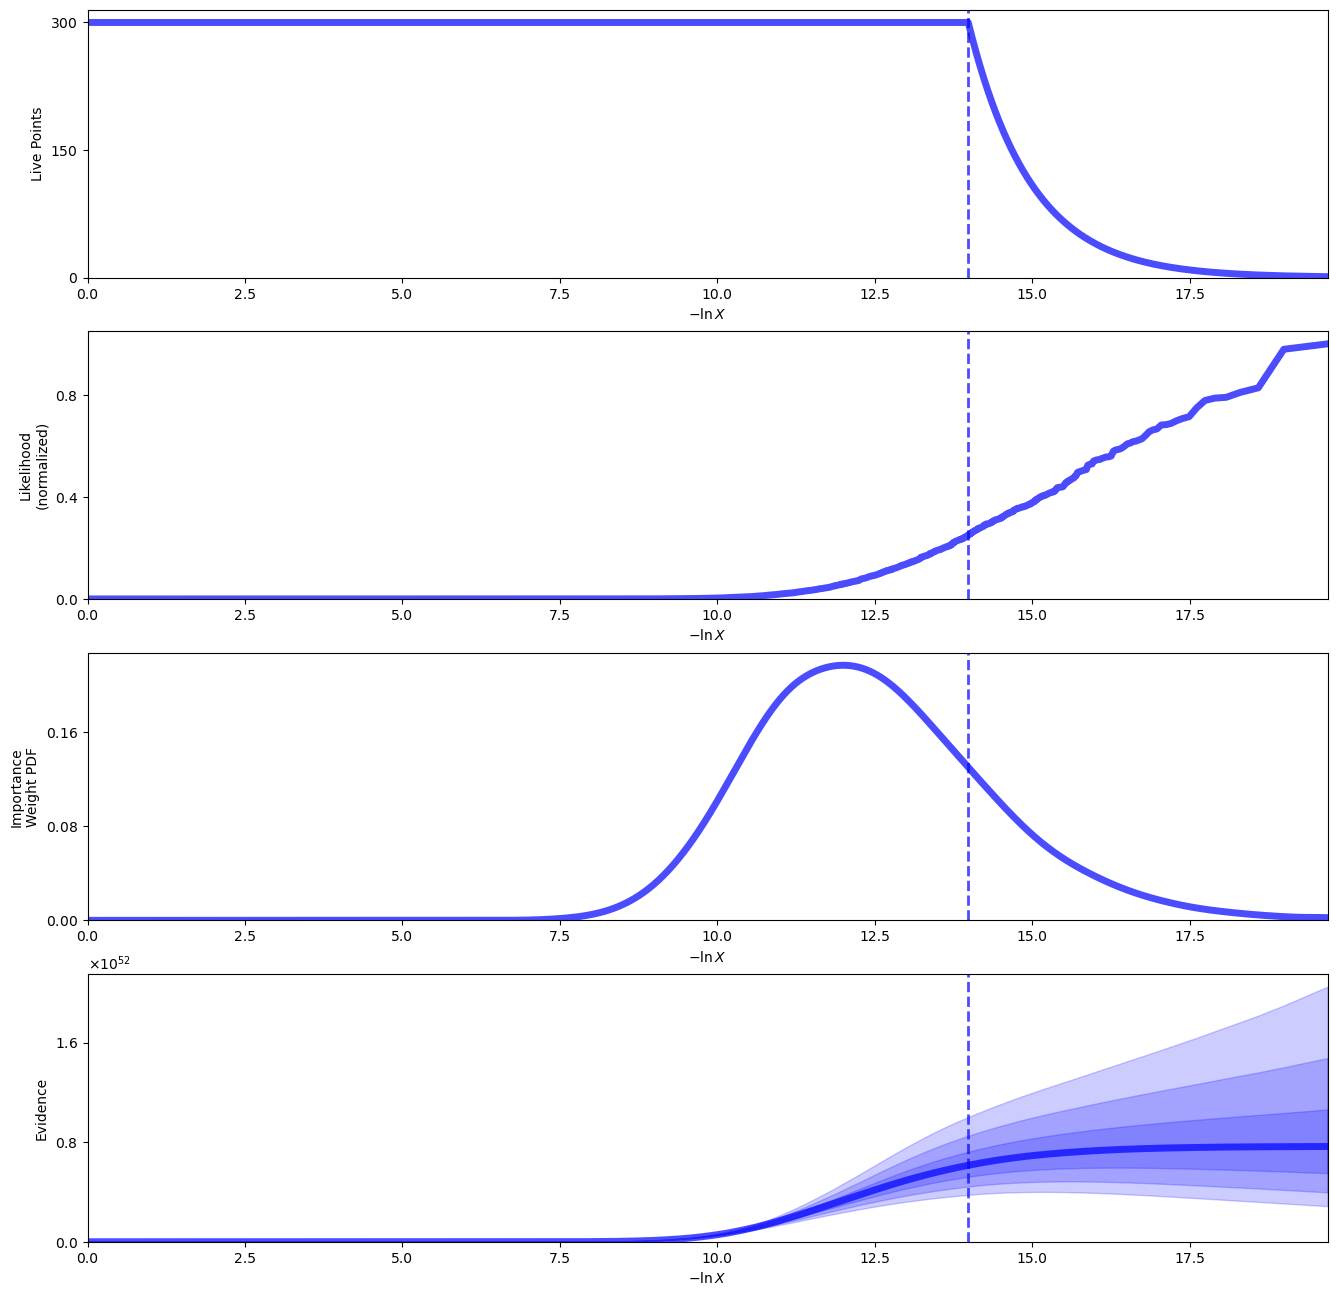

In [11]:
fig, axes = dyplot.runplot(results_dyn) 

Nested sampling works by iteratively concentrating a set of "live points" in the prior volume ($X$ in the figures) on successively higher likelihood contours. This allows it to estimate the Bayesian evidence along with the posterior, and gives it very well defined stopping criteria. See the [dynesty docs](https://dynesty.readthedocs.io/en/v3.0.0/overview.html) for more details.

## Comparing posteriors

Corner plot overlaying the prior, emcee posterior, and dynesty
posterior. Red dashed lines mark the true parameter values used to
generate the mock data.

Text(0.5, 1.01, 'Posterior comparison: n + $^{40}$Ca OMP calibration')

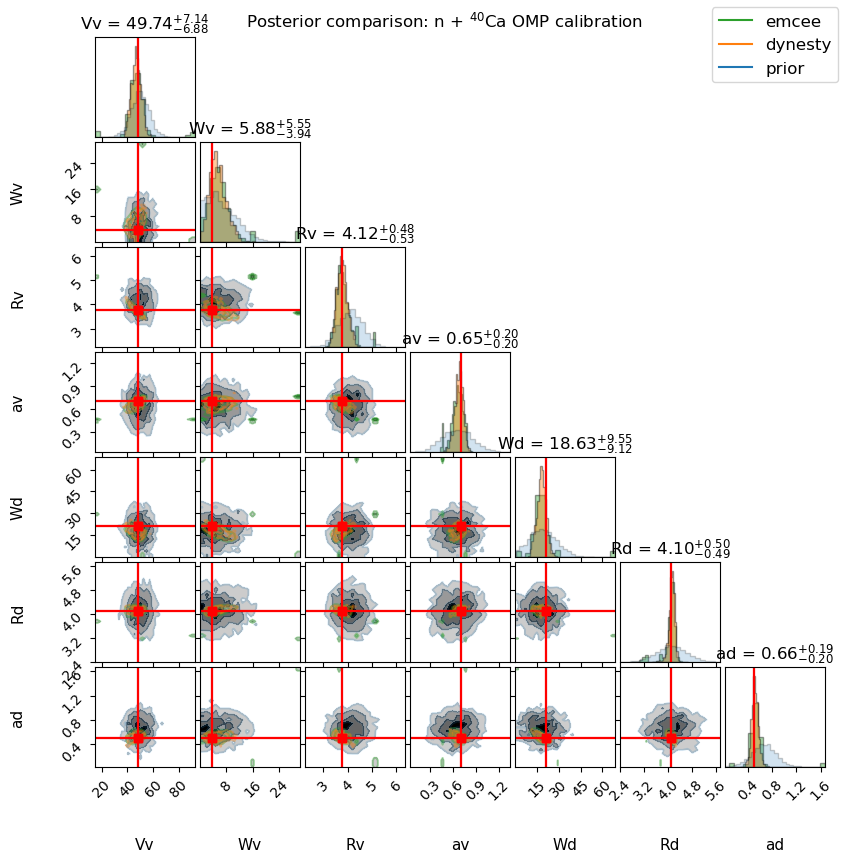

In [12]:
n_corner = 2000
rng_plot = np.random.default_rng(1)
prior_samples = prior.rvs(n_corner)
idx_e = rng_plot.choice(len(flat_emcee), min(n_corner, len(flat_emcee)), replace=False)
idx_d = rng_plot.choice(
    len(flat_dynesty), min(n_corner, len(flat_dynesty)), replace=False
)

fig = plt.figure(figsize=(8, 8))


def corner_kwargs(color, alpha=0.4):
    return dict(
        labels=config.parameter_names,
        truths=true_params,
        truth_color="red",
        label_kwargs={"fontsize": 11},
        show_titles=True,
        plot_datapoints=False,
        plot_density=False,
        plot_contours=True,
        fill_contours=True,
        no_fill_contours=False,
        contour_kwargs={
            "colors": color,
            "linewidths": 1.5,
            "alpha": alpha,
        },
        hist_kwargs={
            "density": True,
            "histtype": "stepfilled",
            "alpha": alpha,
            "color": color,
            "edgecolor": "k",
        },
        labelpad=0.4,
    )


corner.corner(
    flat_emcee[idx_e],
    fig=fig,
    **corner_kwargs("tab:green"),
)
corner.corner(
    flat_dynesty[idx_d],
    fig=fig,
    **corner_kwargs("tab:orange"),
)
corner.corner(
    prior_samples,
    fig=fig,
    **corner_kwargs("tab:blue", alpha=0.2),
)

# Legend
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], color="tab:green", label="emcee"),
    Line2D([0], [0], color="tab:orange", label="dynesty"),
    Line2D([0], [0], color="tab:blue", label="prior"),
]
fig.legend(handles=handles, loc="upper right", fontsize=12)
fig.suptitle(r"Posterior comparison: n + $^{40}$Ca OMP calibration", y=1.01)

While Markov-chain based samplers like the one in emcee are typically great, nested sampling is often better suited when the posterior has multi-modality. 

Here, however, we can see in the emcee posterior that different modes appear, whereas the dynesty posterior is unimodal. By looking at the trace plots for the emcee calibration above, we can see the culprit: certain chains inn the emcee ensemble get "stuck" in a particular region of parameter space, leading to poor mixing between chains. This is indicated by the high auto correlation length of the emcee samples (and rank or rhat analysis would likely corroborate this). This leads us to conclude that the emcee calibration is poorly converged, and the anamolous modes aren't true multi-modality in the posterior (which dynesty would be able to resolve).

Next, we will see how this plays out in the predictive posteriors.

## Comparing predictive posteriors

We propagate 200 posterior samples from each method through the model and show
the 5th–95th percentile predictive band.

In [13]:
n_pred = 200
rng_pred = np.random.default_rng(2)

idx_e_pred = rng_pred.choice(len(flat_emcee), n_pred, replace=False)
idx_d_pred = rng_pred.choice(len(flat_dynesty), n_pred, replace=False)

y_pred_emcee = np.array(
    [omp.visualizable_model_prediction(obs, *s) for s in flat_emcee[idx_e_pred]]
)
y_pred_dynesty = np.array(
    [omp.visualizable_model_prediction(obs, *s) for s in flat_dynesty[idx_d_pred]]
)
y_true_vis = omp.visualizable_model_prediction(obs, *true_params)

angles_plot = np.rad2deg(obs.visualization_workspace.angles)

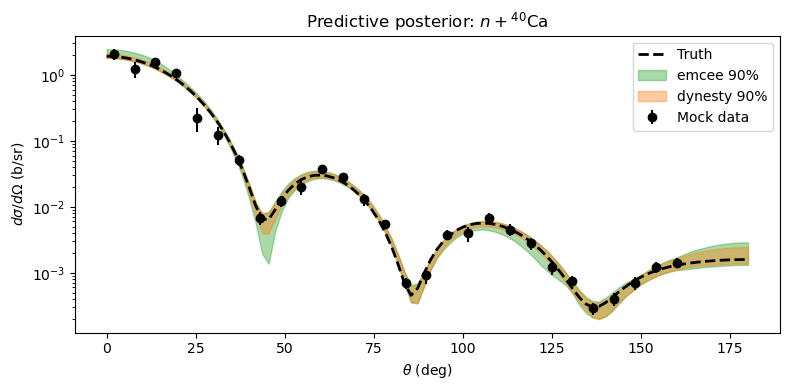

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    np.rad2deg(obs.x),
    obs.y,
    yerr=obs.y_stat_err,
    fmt="ko",
    label="Mock data",
    zorder=5,
)
ax.plot(angles_plot, y_true_vis, "k--", lw=2, label="Truth")

for y_pred, label, color in [
    (y_pred_emcee, "emcee 90%", "tab:green"),
    (y_pred_dynesty, "dynesty 90%", "tab:orange"),
]:
    lo, hi = np.percentile(y_pred, [5, 95], axis=0)
    ax.fill_between(angles_plot, lo, hi, alpha=0.4, color=color, label=label)

ax.set_yscale("log")
ax.set_xlabel(r"$\theta$ (deg)")
ax.set_ylabel(r"$d\sigma/d\Omega$ (b/sr)")
ax.legend()
ax.set_title(r"Predictive posterior: $n + {}^{40}$Ca")
fig.tight_layout()